## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.backends.backend_pdf import PdfPages
import torch
import sys
import os
from torch.utils.data import DataLoader, random_split
import wandb
import random
import datetime

current_dir = os.path.dirname(os.path.abspath(''))
two_up_dir = os.path.dirname(os.path.dirname(current_dir))
sys.path.append(two_up_dir)

from TinyCenterSpeed.src.models.resnet import *
from TinyCenterSpeed.src.models.CenterSpeed import *
from TinyCenterSpeed.dataset.CenterSpeed_dataset import *
from TinyCenterSpeed.src.models.losses import *
from train import *


%env "WANDB_NOTEBOOK_NAME" "centerspeed.ipynb"
print(wandb.__version__)
wandb.login()

env: "WANDB_NOTEBOOK_NAME"="centerspeed.ipynb"
0.21.1


wandb: Currently logged in as: whdaudpark (whdaudpark-dongguk-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Load Data

In [5]:
def cartesian_to_pixel(x, y, image_size=[64,64], pixel_size=0.1):
    pixel_x = int(x / pixel_size + image_size[0] / 2)
    pixel_y = int(y / pixel_size + image_size[1] / 2)
    return pixel_x, pixel_y

transform = transforms.Compose([RandomRotation(45),
                                RandomFlip(0.5)])

# /home/harry/sim_ws/src/f1tenth_gym_ros/Train_GT

# set = CenterSpeedDataset('/home/harry/sim_ws/src/f1tenth_gym_ros/Train_GT', transform=None, dense=True)
# set = CenterSpeedDataset('/home/harry/ros2_ws/src/TinyCenterSpeed/dataset/data/TinyCenterSpeed_dataset/data/CenterSpeedDataset', transform=None, dense=True)

set = CenterSpeedDataset('/home/harry/sim_ws/src/f1tenth_gym_ros/Train_GT', transform=None, dense=True)



set.seq_len = 2
set.sx = 1 #0.9
set.sy = 1 #0.9
set.change_image_size(64)
set.change_pixel_size(0.1)

# independent_test_set = LidarDatasetSeqOD('../../dataset/data/validation_set.csv')
# independent_test_set.seq_len = 2




Reading the following files:  /home/harry/sim_ws/src/f1tenth_gym_ros/Train_GT/TrainGT_redbull_obs2_100s.csv
Number of entries:  3707
Reading the following files:  /home/harry/sim_ws/src/f1tenth_gym_ros/Train_GT/TrainGT_redbull_obs3_100s.csv
Number of entries:  4154
Reading the following files:  /home/harry/sim_ws/src/f1tenth_gym_ros/Train_GT/TrainGT_redbull_obs1_100s.csv
Number of entries:  4279
Number of rows:  12140
File indices:  [(0, 3707), (3707, 7861), (7861, 12140)]
Image size changed to:  64
Origin offset changed to:  2.56
Pixel size changed to:  0.1
Origin offset changed to:  3.2


Using dense features with data: tensor([ 2.8487,  0.0956, -0.2606, -0.0000, -3.1416])
Data: GT


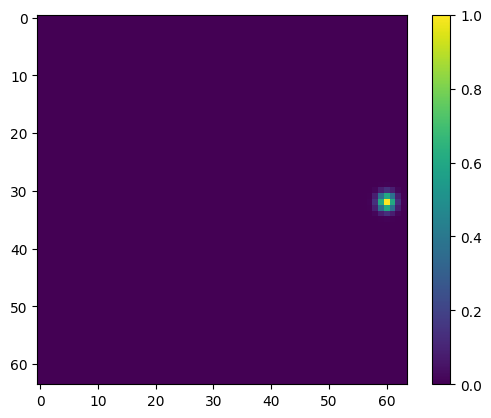

Dense data shape: torch.Size([64, 64, 3])
Data: VX
Maximum from data: -0.2606232464313507
Maximum value in image slice 0: -0.0
Minimum value in image slice 0: -0.2606232464313507


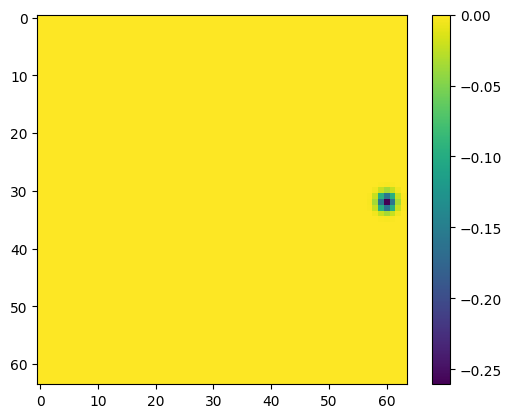

Data: VY
Maximum from data: -0.0
Maximum value in image slice 1: -0.0
Minimum value in image slice 1: -0.0


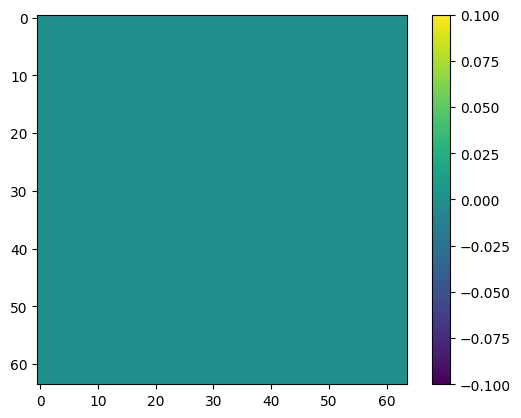

Data: YAW
Maximum from data: -3.1415927410125732
Maximum value in image slice 2: -0.0
Minimum value in image slice 2: -3.1415927410125732


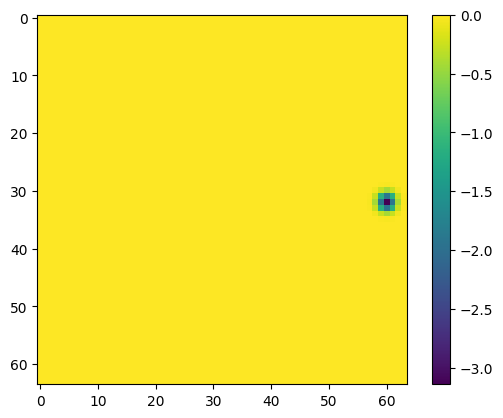

In [6]:
input, gt_heatmap, data, dense_data, is_free = set[129]
print(f'Data: GT')
plt.imshow(gt_heatmap)
plt.colorbar()
plt.show()

labels = ['VX', 'VY', 'YAW']
print(f'Dense data shape: {dense_data.shape}')

for i in range(dense_data.shape[2]):
    plt.imshow(dense_data[:,:,i])
    print(f'Data: {labels[i]}')
    print(f'Maximum from data: {data[i+2].item()}')
    # Extract and print the maximum value
    max_value = np.max(dense_data[:,:,i].numpy().flatten())
    min_value = np.min(dense_data[:,:,i].numpy().flatten())
    print(f"Maximum value in image slice {i}: {max_value}")
    print(f"Minimum value in image slice {i}: {min_value}")
    plt.colorbar()
    plt.show()



In [ ]:
# ### TEST THE MODEL

# model = CenterSpeedDense()
# model.eval()

# output = model(input.unsqueeze(0))

# plt.imshow(input[0])
# plt.show()
# # for i in range(output.shape[1]):
# #     # plt.imshow(output[0,i].detach().numpy())
# #     plt.colorbar()
# #     plt.show()

# # print(output)
# # print("input has NaN:", torch.isnan(input).any().item())
# # for c in range(input.shape[0]):
# #     print(c, torch.isnan(input[c]).sum().item())


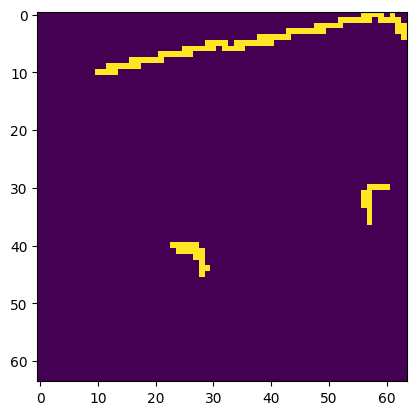

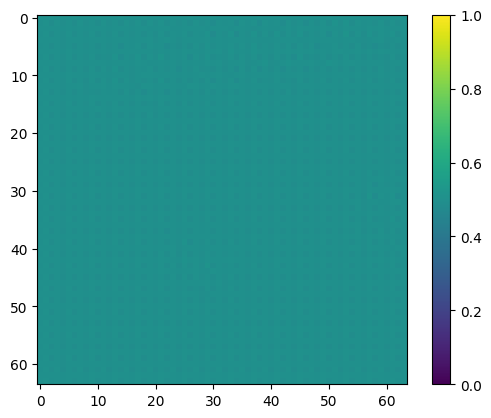

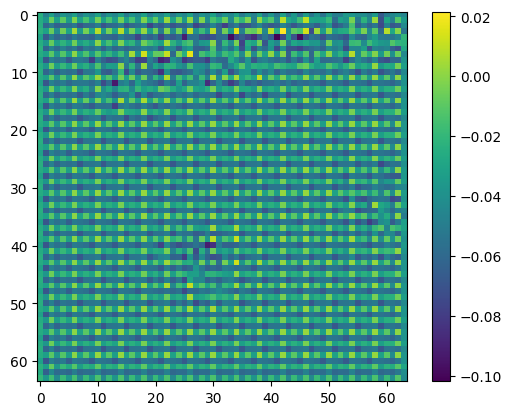

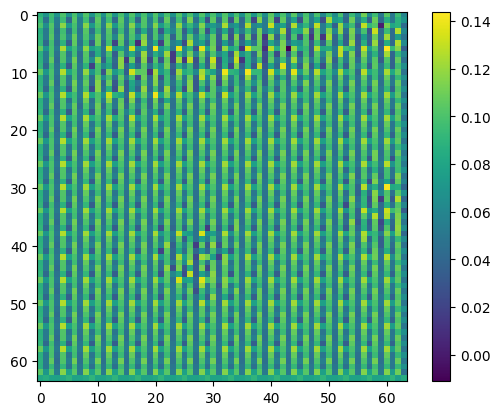

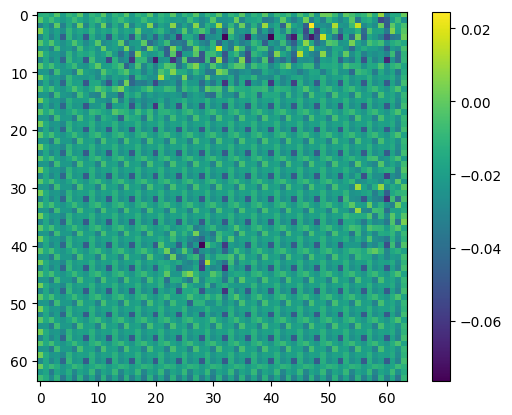

In [7]:

model = CenterSpeedDense()
model.eval()

# ⛑️ 입력 안전화: NaN/Inf → 0, 과도한 값 클램프
def sanitize_tensor(x):
    x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    return torch.clamp(x, -1e6, 1e6)

with torch.no_grad():
    input = sanitize_tensor(input)
    output = model(input.unsqueeze(0))          # BCHW

# 입력 확인
plt.imshow(input[0].detach().cpu().numpy())
plt.show()

# 🔎 채널별 시각화 (heatmap은 sigmoid로 확률화, dense는 그대로)
with torch.no_grad():
    heat_prob = torch.sigmoid(output[0,0]).cpu().numpy()
    plt.imshow(heat_prob, vmin=0, vmax=1); plt.colorbar(); plt.show()
    for i in range(1, output.shape[1]):  # 1: vx, 2: vy, 3: yaw 라고 가정
        arr = output[0,i].detach().cpu().numpy()
        arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
        plt.imshow(arr); plt.colorbar(); plt.show()



In [ ]:
# ### new Loss funcction

# def dense_loss(output, gt_heatmap, gt_dense_data, is_free, alpha=0.7, decay=1):
#     print(f'Output Shape: {output.shape}')
#     print(f'GT Heatmap Shape: {gt_heatmap.shape}')
#     print(f'GT Dense Shape: {gt_dense_data.shape}')
#     # fig, ax = plt.subplots(1,3, figsize=(15,5))
#     # ax[0].imshow(gt_heatmap[0])
#     # ax[0].set_title('GT Heatmap')
#     # ax[1].imshow(gt_dense_data[:,:,:,0].squeeze())
#     # ax[1].set_title('GT Dense Data')
#     # ax[2].imshow(output[0,:,:,0].squeeze().detach().numpy())


#     loss = 0
#     batch_size = output.shape[0]

#     w = gt_heatmap # unit heatmap

#     loss += (alpha * (1+w)* (output[:,:,:,0].unsqueeze(-1) - gt_heatmap)**2).sum()
#     loss += ((1-alpha) * (1+w)* (output[:,:,:,1:] - gt_dense_data)**2).sum()

#     return loss/ batch_size
# print(f'Output Shape: {output.shape}')
# plt.imshow(output[0,0].detach().numpy())
# plt.show()
# loss = dense_loss(output.permute(0,2,3,1), gt_heatmap.unsqueeze(0).unsqueeze(-1), dense_data.unsqueeze(0), is_free)
# # print(f'Loss: {loss.item()}')



In [ ]:
def dense_loss(output_bhwc, gt_heatmap_bhw1, gt_dense_bhw3, is_free_bhw1,
               alpha=0.7, decay=1, eps=1e-8):
    """
    output_bhwc:  [B,H,W,4]  (0: heatmap(logit), 1: vx, 2: vy, 3: yaw)
    gt_heatmap_bhw1: [B,H,W,1]
    gt_dense_bhw3:   [B,H,W,3]
    is_free_bhw1:    [B,H,W,1]  1: free, 0: occupied (필요에 따라 반대로 쓰면 not연산)
    """
    # ⛑️ 모든 텐서 안전화
    def sani(t):
        t = torch.nan_to_num(t, nan=0.0, posinf=0.0, neginf=0.0)
        return torch.clamp(t, -1e6, 1e6)

    output_bhwc     = sani(output_bhwc)
    gt_heatmap_bhw1 = sani(gt_heatmap_bhw1)
    gt_dense_bhw3   = sani(gt_dense_bhw3)
    is_free_bhw1    = sani(is_free_bhw1)

    B = output_bhwc.shape[0]
    w = gt_heatmap_bhw1                      # 가중치용(필요시 정규화)
    w = torch.nan_to_num(w, nan=0.0)         # NaN 제거
    one_plus_w = 1.0 + w

    # 🔹 heatmap은 보통 로짓 → sigmoid 후 MSE 보다는 BCEWithLogits가 더 일반적
    # 여기선 원 코드 유지(MSE)하되, 로짓→확률로 바꿔 비교하면 학습 안정
    heat_logit = output_bhwc[..., 0:1]
    heat_prob  = torch.sigmoid(heat_logit)

    # 🔹 마스크가 'free=1'이면, 학습 가중을 free/occupied에 다르게 둘 수도 있음
    #    (여기선 원 로직대로 one_plus_w만 적용)
    hm_loss = ((heat_prob - gt_heatmap_bhw1)**2 * one_plus_w).sum()

    dense_pred = output_bhwc[..., 1:4]       # vx, vy, yaw
    dense_loss_val = ((dense_pred - gt_dense_bhw3)**2 * one_plus_w).sum()

    loss = alpha * hm_loss + (1 - alpha) * dense_loss_val
    return loss / max(B, 1)


## Parameter Definition

In [ ]:
use_wandb = True
save_code = True
# Define the hyperparameters, logged in wandb
epochs = 15
learning_rate = 5e-4
learning_rate_hm = 0.005
learning_rate_head = 0.005
architecture = "CenterSpeed: Hourglass Deep with Sigmoid, & Dropout, BatchNorm and Head with 2 frames, lower resolution: 64x64, pixelsize 0.1"
dataset = "Transfer learning test"
optimizer = "Adam"
batch_size = 32
timer = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
run_name = "CenterSpeed_" + timer
loss_used = "CenterSpeedLossFreev2 with updated logic for free tracks on the dataset level"

#wandb configurations
config = {
    "epochs": epochs,
    "learning_rate": learning_rate,
    "architecture": architecture,
    "dataset": dataset,
    "optimizer": optimizer,
    "Loss-Function": loss_used
}
if use_wandb:
    #initialize wandb run
    run = wandb.init(project="CenterSpeedLowRes", config=config, name=run_name, save_code=save_code)#initialize wandb
    wandb.define_metric("epoch")
    wandb.define_metric("train/*", step_metric="epoch")




train_size = int(len(set) * 0.8)  # 80% for training
val_size = int(len(set) * 0.1)  # 0% for validation since this set is seperate!
test_size = len(set) - (train_size + val_size)  # Remaining 5% for testing

train_dataset, val_dataset, test_dataset = random_split(set, [train_size, val_size, test_size])


training_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
testing_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
validation_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle= False)

print("Size of Training Set: ", len(train_dataset))
print("Size of Testing Set: ", len(test_dataset))
print("Size of Validation Set: ", len(val_dataset))

net = CenterSpeedDense(image_size=64)

optimizer = torch.optim.Adam(net.parameters(), lr= learning_rate)
print("Optimizer Initialized")

loss_fn = dense_loss
print("Loss function initialized")

In [ ]:
def print_learning_rates(optimizer):
    for i, param_group in enumerate(optimizer.param_groups):
        print(f"Learning rate of layer {i}: {param_group['lr']}")

print_learning_rates(optimizer)

net.train()

for name, param in net.named_parameters():
    if param.requires_grad:
        print("GRAD: ", name)
    else:
        print("NO GRAD: ", name)

## Training

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

In [ ]:
from IPython.display import clear_output, display

def train_epoch_Centerspeed_dense(training_loader, net, optimizer, loss_fn,
                                  device='cpu', use_wandb=True, pdf=None):
    net.train()
    running_loss = 0.0
    total_batches = len(training_loader)

    def sani(t):
        t = torch.nan_to_num(t, nan=0.0, posinf=0.0, neginf=0.0)
        return torch.clamp(t, -1e6, 1e6)

    for i, batch in enumerate(training_loader):
        inputs, gts, data, dense_data, is_free = batch

        # ✅ to(device) + sanitize
        inputs     = sani(inputs.to(device, dtype=torch.float32, non_blocking=True))
        gts        = sani(gts.to(device, dtype=torch.float32, non_blocking=True))
        data       = sani(data.to(device, dtype=torch.float32, non_blocking=True))
        dense_data = sani(dense_data.to(device, dtype=torch.float32, non_blocking=True))
        is_free    = sani(is_free.to(device, dtype=torch.float32, non_blocking=True))

        optimizer.zero_grad()

        # ⛳️ 모델 출력은 BCHW → BHWC로 변환해 손실에 전달(일관성 유지)
        output_bchw = net(inputs)
        output_bhwc = output_bchw.permute(0, 2, 3, 1).contiguous()

        # GT도 BHWC로 맞춤
        gts_bhw1      = gts.unsqueeze(-1)         # [B,H,W,1]
        dense_bhw3    = dense_data                 # 이미 [B,H,W,3]로 제공된다고 가정
        is_free_bhw1  = is_free                    # [B,H,W,1]

        loss = loss_fn(output_bhwc, gts_bhw1, dense_bhw3, is_free_bhw1)

        loss.backward()
        optimizer.step()

        running_loss += float(loss.detach().cpu().item())
        if use_wandb:
            wandb.log({"train/batch_loss": float(loss.detach().cpu().item())}, commit=False)

    return running_loss / max(total_batches, 1)


# def train_epoch_Centerspeed_dense(training_loader, net, optimizer, loss_fn,
#                                   device='cpu', use_wandb=True, pdf=None):
#     net.train()
#     running_loss = 0.0
#     total_batches = len(training_loader)

#     # (선택) 시각화는 학습 느려지니 필요할 때만 쓰자
#     # plt.ion()
#     # fig, ax = plt.subplots(1,3, figsize=(15,5))

#     for i, batch in enumerate(training_loader):
#         inputs, gts, data, dense_data, is_free = batch

#         # ✅ 모두 같은 디바이스/타입으로
#         inputs     = inputs.to(device, dtype=torch.float32, non_blocking=True)
#         gts        = gts.to(device, dtype=torch.float32, non_blocking=True)
#         data       = data.to(device, dtype=torch.float32, non_blocking=True)
#         dense_data = dense_data.to(device, dtype=torch.float32, non_blocking=True)
#         is_free    = is_free.to(device, dtype=torch.float32, non_blocking=True)

#         optimizer.zero_grad()
#         output = net(inputs)  # 보유 모델은 BHWC: [B, H, W, 4]

#         # 🔴 permute 금지 (이미 BHWC)
#         # loss = loss_fn(output.permute(0,2,3,1), gts.unsqueeze(-1), dense_data, is_free)  # X
#         loss = loss_fn(output.permute(0, 2, 3, 1), gts.unsqueeze(-1), dense_data, is_free)

#         loss.backward()
#         optimizer.step()

#         running_loss += loss.item()

#         # 🔹 배치 로깅(에폭 끝나기 전에도 차트 보이게). commit=False로 모아 보내기
#         if use_wandb:
#             wandb.log({"train/batch_loss": loss.item()}, commit=False)

#         # print(f'  batch {i+1} loss: {loss.item():.6f}')

#     avg_loss = running_loss / max(total_batches, 1)

#     # 마지막 배치 손실이 아니라, 에폭 평균을 반환해야 함
#     return avg_loss


In [ ]:
import time
# import wandb
# import matplotlib.pyplot as plt

# (wandb.init은 위 셀에서 이미 했으니 여기서는 하지 않습니다)

net.to(device)

EPOCHS = 100
losses = []
epoch_times = []  # 각 epoch 소요 시간 기록

for epoch in range(EPOCHS):
    start_time = time.time()  # ⏳ 에포크 시작 시간
    print(f'Epoch: {epoch+1}/{EPOCHS}')
    
    net.train()
    avg_loss = train_epoch_Centerspeed_dense(
        training_loader=training_loader,
        net=net,
        optimizer=optimizer,
        loss_fn=loss_fn,
        device=device,
        use_wandb=True
    )

    losses.append(avg_loss)

    # ✅ W&B 로깅: Epoch별 Train Loss
    wandb.log({"epoch": epoch, "train/loss": avg_loss}, commit=True)

    # 모델 저장 (EPOCHS=100일 때 마지막도 저장하려면 (epoch+1) % 10 == 0 으로)
    if (epoch+1) % 10 == 0:
        model_path = f'../trained_models/redbull_0811_epoch_{epoch}.pt'
        torch.save(net.state_dict(), model_path)

    # ⏳ 에포크 시간 측정
    end_time = time.time()
    elapsed = end_time - start_time
    epoch_times.append(elapsed)

    # 남은 시간 계산 (평균 에포크 시간 × 남은 epoch 수)
    avg_epoch_time = sum(epoch_times) / len(epoch_times)
    remaining_epochs = EPOCHS - (epoch + 1)
    remaining_time = avg_epoch_time * remaining_epochs

    # 시간 보기 좋게 변환
    mins, secs = divmod(int(remaining_time), 60)
    print(f"⏱ 예상 남은 학습 시간: {mins}분 {secs}초")

# 📊 손실 그래프
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.show()

print("W&B run URL:", wandb.run.url)

# W&B 종료
wandb.finish()

# # (wandb.init은 위 셀에서 이미 했으니 여기서는 하지 않습니다)

# net.to(device)

# EPOCHS = 3
# losses = []

# for epoch in range(EPOCHS):
#     print(f'Epoch: {epoch}')
#     net.train()
#     avg_loss = train_epoch_Centerspeed_dense(
#         training_loader=training_loader,
#         net=net,
#         optimizer=optimizer,
#         loss_fn=loss_fn,
#         device=device,
#         use_wandb=True
#     )

#     losses.append(avg_loss)

#     # ✅ W&B 로깅: Epoch별 Train Loss
#     wandb.log({"epoch": epoch, "train/loss": avg_loss}, commit=True)

#     # 모델 저장 (EPOCHS=10일 때 마지막도 저장하려면 (epoch+1) % 10 == 0 으로)
#     if (epoch + 1) % 3 == 0:
#         model_path = f'../trained_models/dense_epoch_{epoch}.pt'
#         torch.save(net.state_dict(), model_path)
#         # 원하면 W&B 아티팩트로 업로드:
#         # art = wandb.Artifact("CenterSpeedDense", type="model")
#         # art.add_file(model_path)
#         # wandb.log_artifact(art)

# plt.plot(losses)
# plt.xlabel("Epoch")
# plt.ylabel("Training Loss")
# plt.title("Training Loss Curve")
# plt.show()


# print("W&B run URL:", wandb.run.url)


# # W&B 종료
# wandb.finish()


In [2]:
for name, param in net.named_parameters():
    if param.grad is None:
        print(name, param.data)
    if param.grad is not None:
        print(name)



NameError: name 'net' is not defined

In [1]:
input = next(iter(training_loader))[0]

import time
input = input.to(device)  # ← 이 줄 추가!
start = time.perf_counter()
output = net(input)
end = time.perf_counter()
print(f'Elapsed time: {(end-start)*1000} ms')
print(f'Input Shape: {input.shape}')
print(f'Output Shape: {output.shape}')

input, gt_heatmap, data, dense_data, is_free = set[100]
output = net(input.unsqueeze(0).to(device))  # ← .to(device) 추가!


NameError: name 'training_loader' is not defined

In [3]:

print(output.shape)

NameError: name 'output' is not defined

In [4]:
# 랜덤 샘플 뽑기
input, gt_heatmap, data, dense_data, is_free = set[np.random.randint(0, len(set))]
input = input.unsqueeze(0)  # [1, C, H, W]

plt.imshow(input[0,0]); plt.show()

# ⛑️ 안전 처리 + 추론 (항상 새 input으로 output 다시 계산!)
def sanitize_tensor(x):
    x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    return torch.clamp(x, -1e6, 1e6)

model.eval()
with torch.no_grad():
    inp = sanitize_tensor(input).to(device)
    out = model(inp)  # out: [1, 4, H, W] (0: heatmap logit, 1: vx, 2: vy, 3: yaw)

    # heatmap은 sigmoid로 확률화
    heat_prob = torch.sigmoid(out[0,0]).cpu().numpy()
    max_index = np.unravel_index(heat_prob.argmax(), heat_prob.shape)

    plt.imshow(heat_prob, vmin=0, vmax=1)
    plt.plot(max_index[1], max_index[0], 'ro')
    plt.colorbar(); plt.show()

    # 나머지 dense 채널 (vx, vy, yaw)
    for i in range(1, out.shape[1]):
        arr = out[0,i].cpu().numpy()
        arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
        plt.imshow(arr); plt.plot(max_index[1], max_index[0], 'ro')
        plt.colorbar(); plt.show()

        # 필요하면 해당 지점 값 비교
        val_at_max = arr[max_index]
        print(f"ch={i}, value@heat-peak: {val_at_max:.4f}")


# input, gt_heatmap, data, dense_data, is_free = set[np.random.randint(0, len(set))]
# input = input.unsqueeze(0)

# plt.imshow(input[0,0])
# plt.show()
# # max_index = np.unravel_index(output[0,0].detach().numpy().argmax(), output[0,0].shape)
# max_index = np.unravel_index(output[0,0].detach().cpu().numpy().argmax(), output[0,0].shape)
# output[0,0] = F.softmax(output[0,0])
# output[0,0] = F.softmax(output[0,0])
# print(data)
# for i in range(output.shape[1]):
#     plt.imshow(output[0,i].detach().cpu().numpy())
#     plt.plot(max_index[1], max_index[0], 'ro')
#     plt.colorbar()
#     plt.show()
#     if i == 0:
#         print(f'Output: Heatmap')
#         continue

#     value_at_max = output[0,i].detach().cpu().numpy()[max_index]
#     max_value = np.max(output[0,i].detach().cpu().numpy())
#     min_value = np.min(output[0,i].detach().cpu().numpy())

#     print(f'GT: {data[1+i]} ')
#     print(f'Output: {value_at_max} ')
#     print(f'Maximum value in image slice {i}: {max_value}')
#     print(f'Minimum value in image slice {i}: {min_value}')


NameError: name 'np' is not defined